# Seurat mapping done by Luke --> redoing dimensionality reduction & clustering

In [1]:
here::i_am("rna/regression/regress_variables.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

# Multi core using future - built in to seurat
plan("multicore", workers = 24)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

args = list()
args$integrated_object = '/rds/project/rds-SDzz0CATGms/users/ltgh2/projects/01_Eomes_invitro_HE_multiome/processed/rna/seurat_objects/all_anchors_20_rPCA.rds'

args$outdir = file.path(io$basedir, 'results/rna/mapping/seurat/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



#### Load Seurat Object

In [2]:
seurat = readRDS(args$integrated_object)

In [11]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell')

In [17]:
meta_eomes = meta[!is.na(extended_celltype_predicted)]

In [19]:
nrow(meta_eomes)

[1] 38346

In [20]:
seurat_eomes = seurat[,meta_eomes$cell]

In [21]:
seurat_eomes

An object of class Seurat 
35634 features across 38346 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 other assay present: RNA

In [23]:
DefaultAssay(seurat_eomes) = "integrated"
seurat_eomes = ScaleData(seurat_eomes, verbose = FALSE) %>%
    RunPCA(., npcs = 30, verbose = FALSE) %>%
    RunUMAP(., reduction = "pca", 
                dims = 1:30,               
                n.neighbors = 25L,
                min.dist = 0.3,
                metric = 'euclidean',
                verbose = F) %>%
    FindNeighbors(., reduction = "pca", dims = 1:30) %>%
    FindClusters(., resolution = 2)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
16:34:09 UMAP embedding parameters a = 0.9922 b = 1.112

16:34:09 Read 38346 rows and found 30 numeric columns

16:34:09 Using Annoy for neighbor search, n_neighbors = 25

16:34:09 Building Annoy index with metric = euclidean, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:34:11 Writing NN index file to temp file /tmp/RtmpJJpwcC/file3b8ed4130a45b

16:34:11 Searching Annoy index using 24 threads, search_k = 2500

16:34:12 Annoy recall = 100%

16:34:13 Commencing smooth kNN distance calibration using 24 threads
 with target n_ne

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 38346
Number of edges: 1386389

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8333
Number of communities: 41
Elapsed time: 10 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


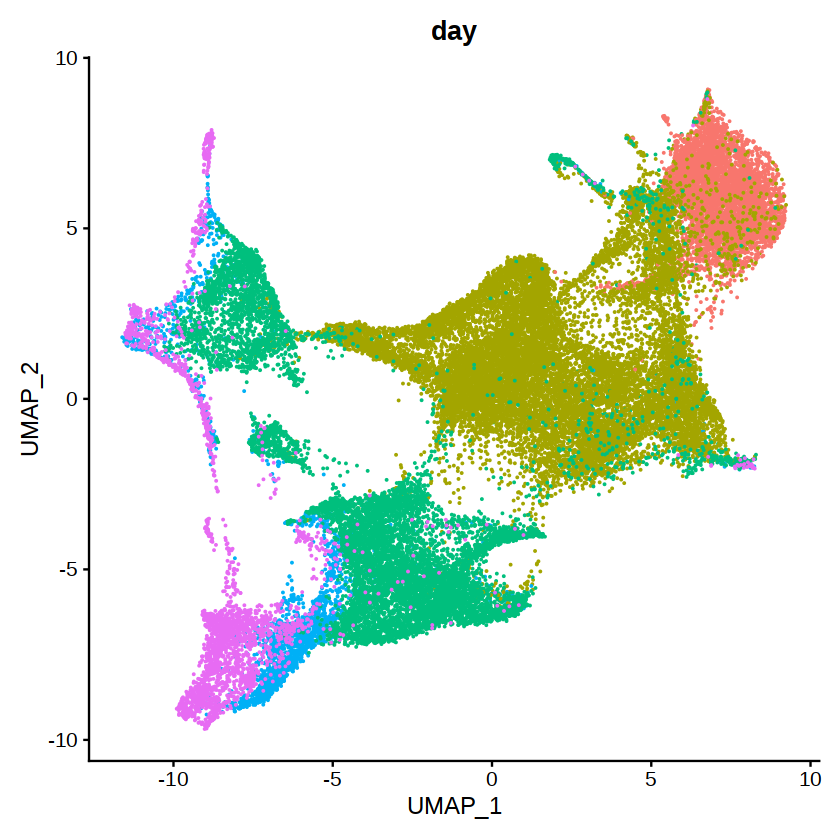

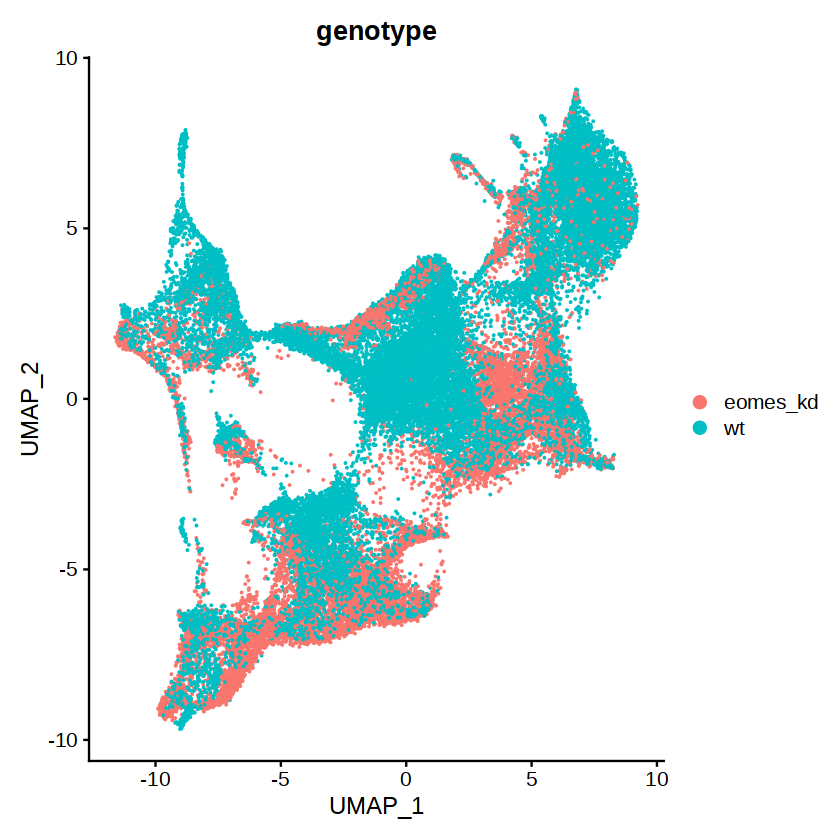

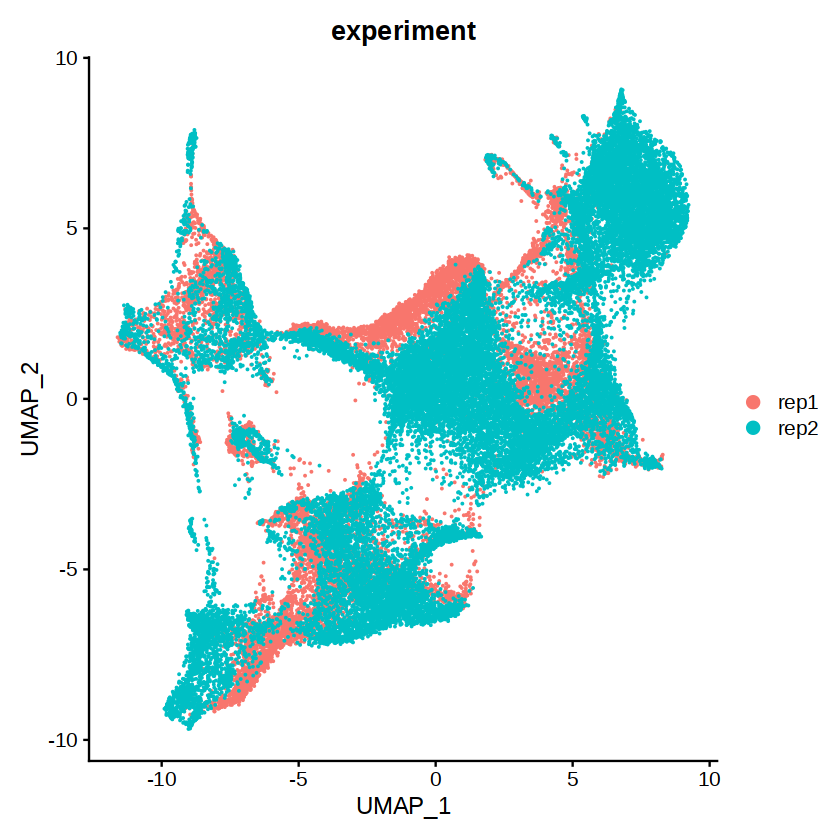

In [27]:
DimPlot(seurat_eomes, reduction = 'umap', group.by = "day") + theme(legend.position='false')
DimPlot(seurat_eomes, reduction = 'umap', group.by = "genotype")
DimPlot(seurat_eomes, reduction = 'umap', group.by = "experiment")